In [1]:
#É possível prever se um passageiro do RMS Titanic sobreviveria ao naufrágio usando seus dados?

#Importando as bibliotecas.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Importando o dataframe
df = pd.read_csv('C:/Users/Gabriel Godoi/Desktop/titanic-ml/data/train.csv')
#Mostrando as 5 primeiras linhas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
#Analisando o dataframe.
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
#Identificando os problemas do dataframe.
#isnull para chamar os dados incompletos.
#sum para somar os dados incompletos e mostrar a quantidade total.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
#Fazer a limpeza dos dados.
#Trocar os valores nulos da coluna 'Age' para a média de idade
df['Age'] = df['Age'].fillna(df['Age'].mean())

#Excluir a coluna 'Cabin'
df = df.drop('Cabin', axis=1)

#Excluir os faltantes da coluna 'Embarked'
df = df.dropna(subset=['Embarked'])   

In [6]:
#Converter strings em numeros.
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

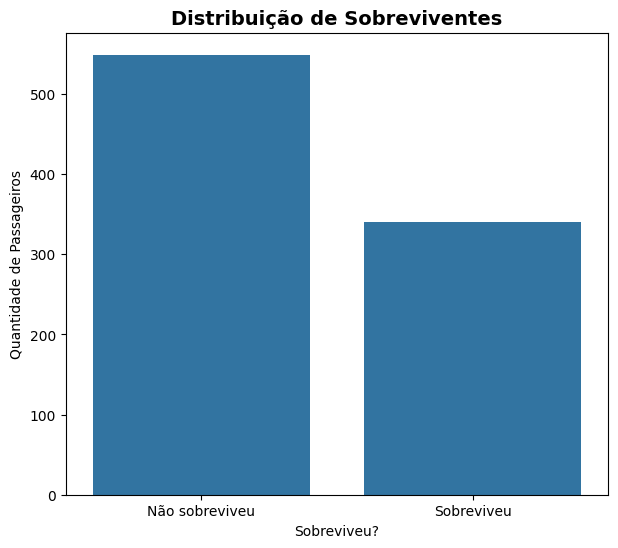

In [7]:
#Ver quantas pessoas sobreviveram
plt.figure(figsize=(7, 6))
sns.countplot(
    x='Survived', 
    data=df
)
plt.title(
    'Distribuição de Sobreviventes',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Sobreviveu?')
plt.ylabel('Quantidade de Passageiros')
plt.xticks(
    ticks=[0,1],
    labels=['Não sobreviveu', 'Sobreviveu']
)
plt.savefig('C:/Users/Gabriel Godoi/Desktop/titanic-ml/images', dpi=300)
plt.show()
#A maioria dos passageiros não sobreviveu ao naufrágio, indicando um dataset desbalanceado com mais casos de morte do que sobrevivência.

O gráfico mostra que a maioria dos passageiros do Titanic não sobreviveu ao desastre. A quantidade de mortes foi significativamente maior do que a de sobreviventes, indicando que as chances de escapar com vida eram relativamente baixas para grande parte das pessoas a bordo.

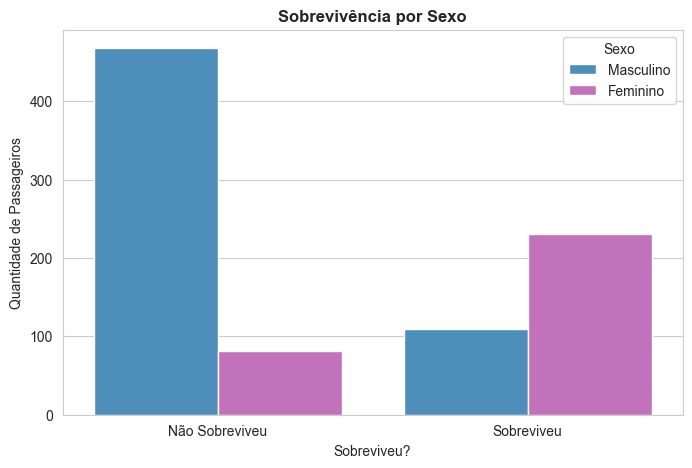

In [8]:
#Sobrevivência por Sexo
#Tamanho do gráfico
plt.figure(figsize=(8,5))
sns.set_style('whitegrid')
#Criando o gráfico
sns.countplot(
    x='Survived', 
    hue='Sex', 
    data=df, 
    palette=["#3c92cc", "#cf63c6"]
)
#Título do gráfico
plt.title(
    'Sobrevivência por Sexo',
    fontweight='bold'
)
plt.xlabel('Sobreviveu?')
plt.ylabel('Quantidade de Passageiros')
#Alterando ticks
plt.xticks(
    ticks=[0,1],
    labels=['Não Sobreviveu', 'Sobreviveu']
)
#Alterando a legenda
plt.legend(
    title='Sexo', 
    labels=['Masculino', 'Feminino']
)
plt.savefig('C:/Users/Gabriel Godoi/Desktop/titanic-ml/images', dpi=300)
plt.show()

Os dados mostram que mulheres tiveram uma taxa de sobrevivência muito maior que homens no desastre do RMS Titanic, indicando prioridade para mulheres na evacuação dos botes salva-vidas.

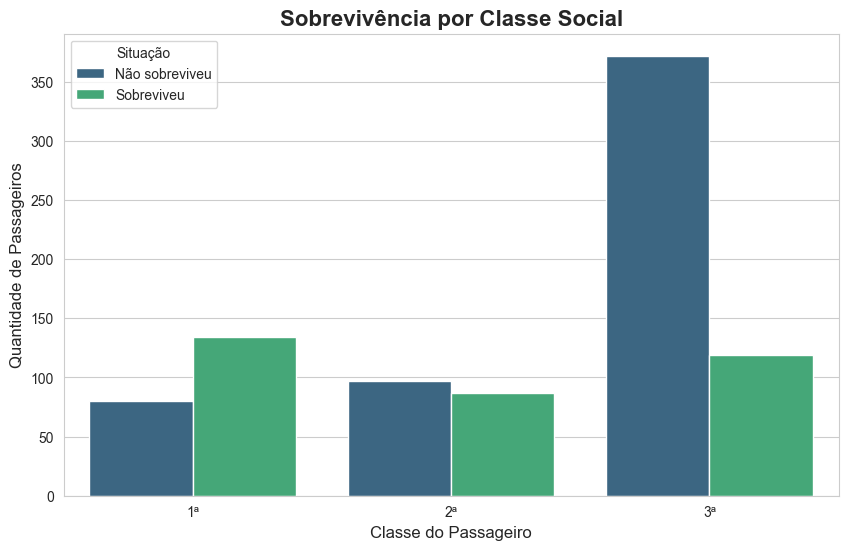

In [9]:
#A classe social influenciou quem sobreviveu no RMS Titanic?
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')
sns.countplot(
    x='Pclass', 
    hue='Survived', 
    data=df,
    palette='viridis'
)
plt.title(
    'Sobrevivência por Classe Social',
    fontsize=16,
    fontweight='bold'
)
plt.legend(
    labels=['Não sobreviveu', 'Sobreviveu'],
    title='Situação'
)
plt.ylabel('Quantidade de Passageiros', fontsize=12)
plt.xlabel('Classe do Passageiro', fontsize=12)
plt.xticks(
    ticks=[0,1,2],
    labels=['1ª', '2ª', '3ª']
)
plt.savefig('C:/Users/Gabriel Godoi/Desktop/titanic-ml/images', dpi=300)
plt.show()






Passageiros da 1ª classe tiveram uma taxa de sobrevivência significativamente maior. Já a 3ª classe apresentou o maior número de mortes, sugerindo que fatores socioeconômicos e localização no navio influenciaram a chance de sobrevivência no naufrágio do RMS Titanic.

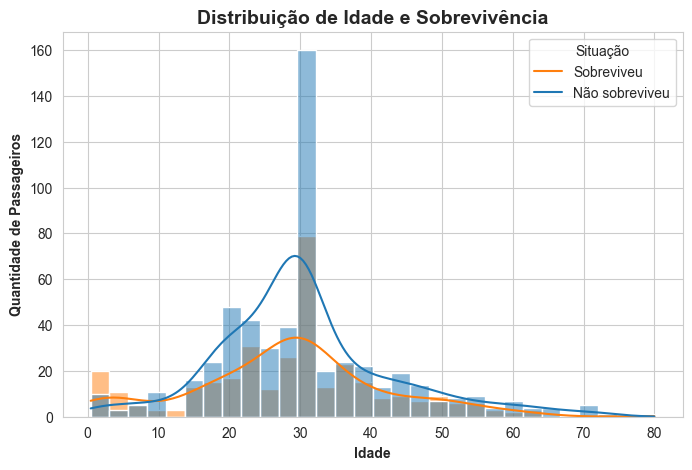

In [10]:
#Pessoas mais jovens tiveram mais chance de sobreviver?
plt.figure(figsize=(8,5))
sns.histplot(
    x= 'Age',
    hue= 'Survived',
    data= df,
    bins= 30,
    kde= True
)
plt.title(
    'Distribuição de Idade e Sobrevivência',
    fontsize=14,
    fontweight='bold'
)
plt.legend(
    title='Situação',
    labels=['Sobreviveu', 'Não sobreviveu']
)
plt.xlabel(
    'Idade',
    fontweight='bold'
)
plt.ylabel(
    'Quantidade de Passageiros',
    fontweight='bold'
)
plt.savefig('C:/Users/Gabriel Godoi/Desktop/titanic-ml/images', dpi=300)
plt.show()

O gráfico mostra que a maioria dos passageiros tinha entre 20 e 35 anos e que a idade, sozinha, não foi um fator determinante para a sobrevivência no desastre do RMS Titanic.

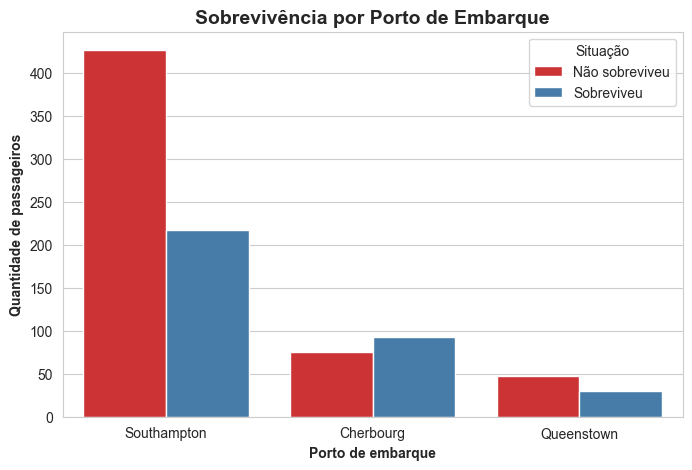

In [11]:
#O porto onde a pessoa embarcou teve alguma influência na sobrevivência?
plt.figure(figsize=(8, 5))
sns.set_style='whitegrid'
sns.countplot(
    x='Embarked',
    hue= 'Survived',
    data= df,
    palette= 'Set1'
)
plt.title(
    'Sobrevivência por Porto de Embarque',
    fontsize= 14,
    fontweight= 'bold'
)
plt.legend(
    title='Situação',
    labels=['Não sobreviveu', 'Sobreviveu']
)
plt.xlabel(
    'Porto de embarque',
    fontweight='bold'
)
plt.ylabel(
    'Quantidade de passageiros',
    fontweight='bold'
)
plt.xticks(
    ticks=[0, 1, 2],
    labels= ['Southampton', 'Cherbourg', 'Queenstown']
)
plt.savefig('C:/Users/Gabriel Godoi/Desktop/titanic-ml/images', dpi=300)
plt.show()

A maioria dos passageiros embarcou em Southampton, onde também ocorreu o maior número de mortes. Já Cherbourg apresentou maior proporção de sobreviventes, sugerindo relação com fatores como classe social no desastre do RMS Titanic.

C:\Users\Gabriel Godoi\AppData\Local\Temp\ipykernel_3792\4217289529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


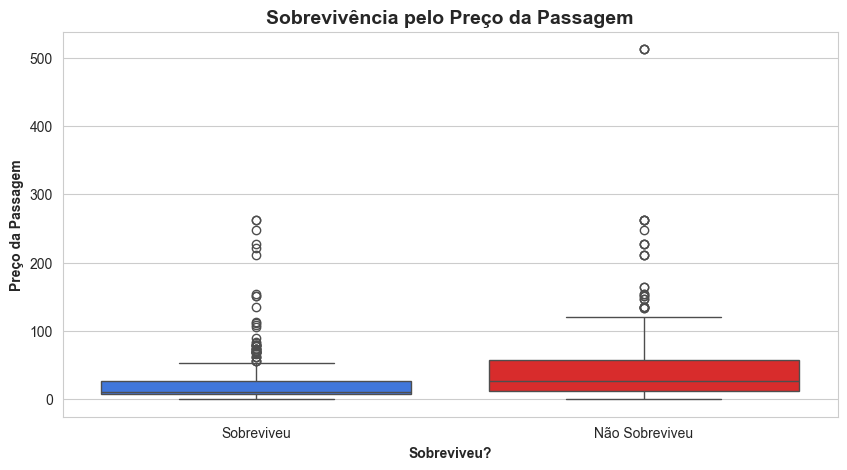

In [12]:
#Quem pagou mais caro no navio teve mais chance de sobreviver?
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='Survived',
    y='Fare',
    data=df,
    palette=['#276ff5', '#f50f0f']
)
plt.title(
    'Sobrevivência pelo Preço da Passagem',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel(
    'Sobreviveu?',
    fontweight='bold'
)
plt.ylabel(
    'Preço da Passagem',
    fontweight='bold'
)
plt.xticks(
    ticks=[0,1],
    labels=['Sobreviveu', 'Não Sobreviveu']
)
plt.savefig('C:/Users/Gabriel Godoi/Desktop/titanic-ml/images', dpi=300)
plt.show()

O gráfico mostra que, em média, passageiros que sobreviveram pagaram passagens mais baratas, enquanto os que não sobreviveram apresentaram preços medianos mais altos, embora existam alguns valores extremos.

In [13]:
#Separando os dados
x = df.drop(['Survived','Name','Ticket','Embarked','PassengerId'], axis=1)
y = df['Survived']

In [14]:
#Separando dados de treino e teste
from sklearn.model_selection import train_test_split
train_test_split(x, y)


[     Pclass  Sex        Age  SibSp  Parch     Fare
 836       3    0  21.000000      0      0   8.6625
 187       1    0  45.000000      0      0  26.5500
 68        3    1  17.000000      4      2   7.9250
 784       3    0  25.000000      0      0   7.0500
 363       3    0  35.000000      0      0   7.0500
 ..      ...  ...        ...    ...    ...      ...
 6         1    0  54.000000      0      0  51.8625
 520       1    1  30.000000      0      0  93.5000
 28        3    1  29.699118      0      0   7.8792
 188       3    0  40.000000      1      1  15.5000
 772       2    1  57.000000      0      0  10.5000
 
 [666 rows x 6 columns],
      Pclass  Sex    Age  SibSp  Parch     Fare
 131       3    0  20.00      0      0   7.0500
 460       1    0  48.00      0      0  26.5500
 873       3    0  47.00      0      0   9.0000
 862       1    1  48.00      0      0  25.9292
 657       3    1  32.00      1      1  15.5000
 ..      ...  ...    ...    ...    ...      ...
 197       3 

In [15]:
#Dividindo os dados
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y,
    test_size=0.2,
    random_state=42
)


In [16]:
#Conferindo se funcionou
print(x_train.shape)
print(x_test.shape)

(711, 6)
(178, 6)


In [17]:
#Importando nosso modelo (Árvore de decisão) e criando a variavel
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [18]:
#Treinando nosso modelo
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
#Fazendo a previsão
predictions = model.predict(x_test)

In [20]:
#Calculando a accuracy do modelo
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
print('Accuracy do modelo:', accuracy)

Accuracy do modelo: 0.797752808988764


In [21]:
#Matriz de confusão
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

[[89 20]
 [16 53]]


In [22]:
#Descobrindo quais fatores mais influenciaram a sobrevivência.
importances = model.feature_importances_
features = pd.Series(importances, index=x.columns)
features.sort_values(ascending=False)


Fare      0.307804
Sex       0.257541
Age       0.255126
Pclass    0.088920
SibSp     0.052592
Parch     0.038017
dtype: float64

In [23]:
#Tradução das variaveis para o gráfico 
nomes_em_portugues = {
    'Fare': 'Preço Passagem',
    'Sex': 'Sexo',
    'Age': 'Idade',
    'Pclass': 'Classe da Cabine',
    'SibSp': 'Irmãos/Cõnjuge a Bordo',
    'Parch': 'Pais/Filhos a bordo'
}
features_pt = features.rename(index=nomes_em_portugues)

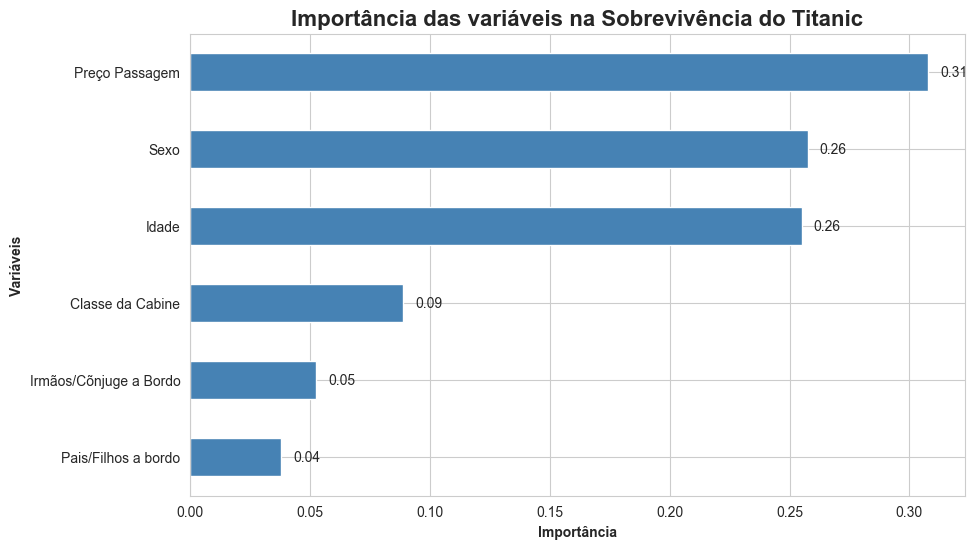

In [24]:
#Grafico dos fatores que mais influenciaram a sobrevicência.
features_sorted = features_pt.sort_values()
plt.figure(figsize=(10,6))
features_sorted.plot(
    kind='barh',
    color='steelblue'
)
plt.title(
    'Importância das variáveis na Sobrevivência do Titanic',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel(
    'Importância',
    fontweight='bold'
)
plt.ylabel(
    'Variáveis',
    fontweight='bold'
)
for i, v in enumerate(features_sorted.values):
    plt.text(v + 0.005, i, f"{v:.2f}", va='center')
plt.savefig('C:/Users/Gabriel Godoi/Desktop/titanic-ml/images', dpi=300)
plt.show()

O gráfico mostra que preço da passagem, sexo e idade foram as variáveis que mais influenciaram a previsão de sobrevivência dos passageiros. Isso indica que fatores como condição econômica, prioridade dada a mulheres e crianças e características demográficas tiveram papel importante durante o desastre do RMS Titanic disaster. As demais variáveis apresentaram menor impacto no modelo, contribuindo menos para a tomada de decisão nas previsões.